### Tissera Ana Paula - `Notebook TP4`

In [116]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Imports

In [117]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import pandas as pd

In [118]:
# uso de cupy en vez de numpy para correrlo en GPU
import cupy as cp

device_id = cp.cuda.Device().id
device_name = cp.cuda.runtime.getDeviceProperties(device_id)['name']

print(f"Usando GPU {device_id}: {device_name}")

Usando GPU 0: b'NVIDIA GeForce RTX 3050 Laptop GPU'


In [119]:
SEED = 42

## `1.` **Clustering de datos**

##### Cargar los datos

In [120]:
clustering_path = "data/clustering.csv"
clustering_df = pd.read_csv(clustering_path)
clustering_df = clustering_df.drop(clustering_df.columns[0], axis=1)

##### Visualización de ejemplo

In [121]:
clustering_df.sample(5, random_state=SEED)

,A,B
84,822368,648690
2470,954037,754046
2804,640123,716370
4987,772586,123935
4924,598444,128607


### `a.` **K-Means** con ganancias decrecientes para determinar K

In [122]:
from src.models import KMeans, find_elbow

In [123]:
# X = clustering_df.values  # asume que el CSV solo contiene las dos columnas de coordenadas
X_cpu = clustering_df.values
X = cp.array(X_cpu)  # pasar a GPU


TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

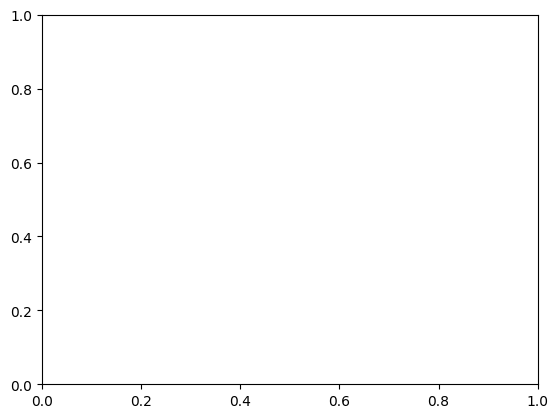

In [ ]:
# plt.scatter(X[:, 0], X[:, 1], s=5, alpha=0.5)
# plt.title("Datos de entrada")

##### $L$ vs. $K$

K =  1 → Inercia = 516864302744182.00
K =  2 → Inercia = 289934063974210.00
K =  3 → Inercia = 182617259354599.00
K =  4 → Inercia = 119781237770822.00
K =  5 → Inercia = 97158902693967.00
K =  6 → Inercia = 79352490290900.00
K =  7 → Inercia = 66442291574055.00
K =  8 → Inercia = 56002180572199.00
K =  9 → Inercia = 45039384213855.00
K = 10 → Inercia = 39506532259043.00
K = 11 → Inercia = 31693774488119.00
K = 12 → Inercia = 24877328816656.00
K = 13 → Inercia = 20833857832204.00
K = 14 → Inercia = 16848986287901.00
K = 15 → Inercia = 13279024047994.00
K = 16 → Inercia = 12878514745437.00
K = 17 → Inercia = 12533515534453.00
K = 18 → Inercia = 12190859497060.00
K = 19 → Inercia = 11827965038787.00

El mejor número de clusters según el método del codo es K = 4


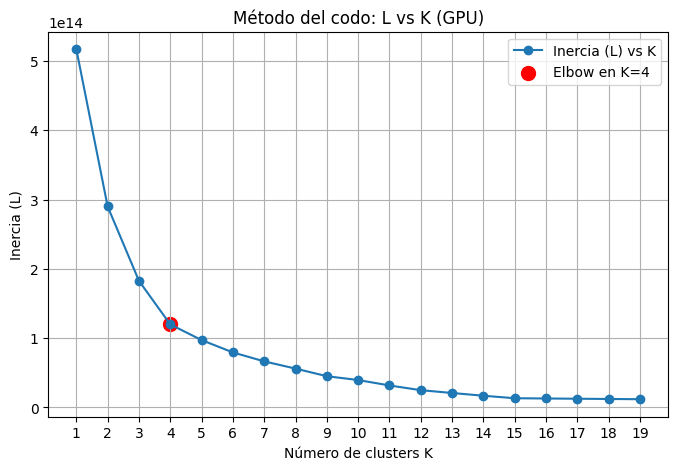

In [125]:
X = cp.array(clustering_df.values)

Ks = list(range(1, 20))
Ls = []
for K in Ks:
    km = KMeans(n_clusters=K, init="k-means++", n_init=10,
                max_iter=300, tol=1e-4, random_state=42)
    km.fit(X)
    print(f"K = {K:2d} → Inercia = {km.inertia_:.2f}")
    Ls.append(km.inertia_)

elbow_idx, distances = find_elbow(Ks, Ls)
bestK = Ks[elbow_idx]
bestL = Ls[elbow_idx]
print(f"\nEl mejor número de clusters según el método del codo es K = {bestK}")

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(Ks, Ls, marker='o', label='Inercia (L) vs K')
plt.scatter([bestK], [bestL], color='red', s=100, label=f'Elbow en K={bestK}')
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia (L)")
plt.title("Método del codo: L vs K (GPU)")
plt.xticks(Ks)
plt.grid(True)
plt.legend()
plt.show()

Inercia final: 13279024047994.00
Iteraciones en la mejor ejecución: 16


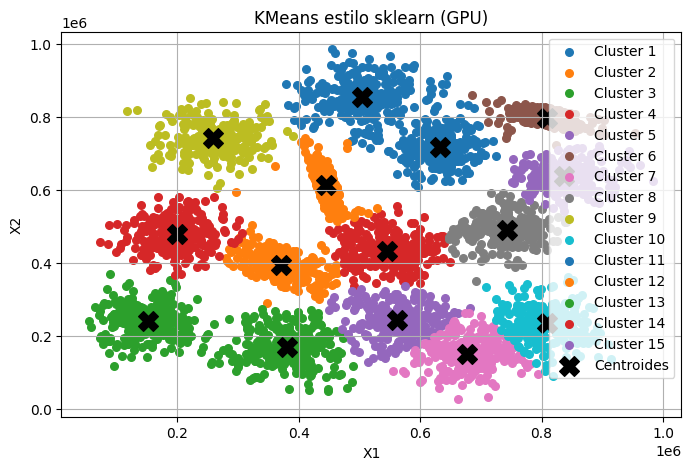

In [128]:
 # Ajustar KMeans
km = KMeans(n_clusters=15, init="k-means++", n_init=10,
            max_iter=300, tol=1e-4, random_state=42)
labels = km.fit_predict(X)

print(f"Inercia final: {km.inertia_:.2f}")
print(f"Iteraciones en la mejor ejecución: {km.n_iter_}")

plt.figure(figsize=(8,5))
for k in range(km.n_clusters):
    pts_k = X[labels == k]                # CuPy array
    x_k = pts_k[:, 0].get()               # NumPy array
    y_k = pts_k[:, 1].get()
    plt.scatter(x_k, y_k, s=30, label=f"Cluster {k+1}")

# Centroides
centers = km.cluster_centers_            # CuPy array
cx = centers[:, 0].get()
cy = centers[:, 1].get()
plt.scatter(cx, cy, marker='X', s=200, c='black', label="Centroides")

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("KMeans estilo sklearn (GPU)")
plt.legend()
plt.grid(True)
plt.show()

##### Gráfico del conjunto $x_i$

### `b.`  Gaussian Mixture Model (**GMM**)

##### inicialización de GMM con una corrida de K-means

### `c.`  **DBSCAN**

##### Variación de los parámetros ε (radio de la vecindad) y $K$ (mínimo número de puntos en una zona densa)

##### Elección de una combinación de ε y K

##### Gráfico de los datos

## `2.` **Reducción de dimensionalidad**

##### Cargar los datos


In [ ]:
MNIST_path = "data/MNIST_dataset.csv"
MNIST_df = pd.read_csv(MNIST_path)

##### Visualización de ejemplo  

In [ ]:
MNIST_df.sample(5, random_state=SEED)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
46730,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
48393,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41416,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34506,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
43725,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### `a.` **PCA**

##### Gráfico de cómo varía el error cuadrático medio de reconstrucción sobre el conjunto de datos en función de la cantidad de componentes principales utilizadas

### `b.` Selección de **componentes principales**

##### Gráfico de las imagenes de los digitos originales y reconstruidos para las primeras 10 muestras del dataset con ... cantidad de componentes

### `c.` Modelo de Autoencoder Variacional (**VAE**) usando PyTorch

##### División en entrenamiento y validación

##### Entrenamiento

##### Comparación con PCA